In [ ]:
import sys
sys.path.append("..")
import jax.numpy as jnp
from jax import grad, config
import matplotlib.pyplot as plt
import numpy as np
config.update("jax_enable_x64", True)
config.update("jax_debug_nans", True)
from models.gw150914_v2_heterodyne import gwfast_LVGW150914
from models.gwfast.waveforms import TaylorF2_RestrictedPN, IMRPhenomD
from src.helper import plot_cross_section
import jax

In [ ]:
model = gwfast_LVGW150914(wf_model=IMRPhenomD, chi=1, eps=0.2, nbins=2000)

In [ ]:
f_min = model.fmin
f_max = model.fmax
chi=1

gammas = jnp.array([-5/3, -2/3, 1, 5/3, 7/3])
f_star = f_max * jnp.heaviside(gammas, 1) + f_min * (1 - jnp.heaviside(gammas, 1))
g = lambda f: 2 * jnp.pi * chi * jnp.sum(jnp.sign(gammas) * ((f / f_star) ** gammas))

g_dense = jax.vmap(g)(model.fgrid)
np.max(g_dense[1:] - g_dense[:-1])        
# sparse_grid = jnp.interp(g_grid, g_dense, model.fgrid) 

In [ ]:
bin_ids = jnp.digitize(model.fgrid, model.sparse_grid) - 1
bin_ids = bin_ids.at[-1].set(len(model.sparse_grid) - 2)

elements_per_bin = jnp.bincount(bin_ids)
assert(np.any(elements_per_bin == 0) == False)

In [ ]:
elements_per_bin == 0

In [ ]:
model.sparse_grid

In [ ]:
bin_ids = jnp.digitize(model.fgrid, model.sparse_grid) - 1
bin_ids = bin_ids.at[-1].set(len(model.sparse_grid) - 2)

elements_per_bin = jnp.bincount(bin_ids)

In [ ]:
elements_per_bin.shape

In [ ]:
elements_per_bin

In [ ]:
np.any(elements_per_bin == 0)

In [ ]:
np.argwhere(elements_per_bin == 0)

In [ ]:
np.allclose(model.B0['L1'], model.A0['L1'].real)

In [ ]:
model.get_summary_data()

In [ ]:
# Lets see what the sparse grid looks like
plt.scatter(model.sparse_grid, np.zeros_like(model.sparse_grid), s=0.1)
plt.xlabel('Frequency')
plt.title('Heterodyne grid')

In [ ]:
# Confirm that the heterodyne function `r` is accurately compressed
x = model._newDrawFromPrior(1)
for det in ['L1', 'H1']:
    r_sparse = model.getSignal_sparse(x)[det] / model.h0[det]
    r_dense = model.getSignal(x)[det] / model.htrue[det]
    plt.plot(model.fgrid, r_dense.squeeze())
    plt.plot(model.sparse_grid, r_sparse.squeeze())

plt.xlabel('Frequency')
plt.ylabel('Strain')
plt.title('Spline compression comparison')

In [ ]:
from models.gw150914_v2_heterodyne import sum_in_bins

def sum_in_bins_naive(arr, f_grid, sparse_grid):
    """
    Naive implementation of summing values in bins defined by sparse_grid.
    """
    b = 0  # Initialize the bin index
    ans = np.zeros(len(sparse_grid) - 1, dtype=arr.dtype)  # Array to store the sums for each bin

    # Iterate through all frequency grid points
    for i in range(len(f_grid)):
        freq = f_grid[i]
        
        # Check if the current frequency is in the current bin
        if sparse_grid[b] <= freq < sparse_grid[b + 1]:
            ans[b] += arr[i]
        
        # Otherwise, find the correct bin
        else:
            # Increment bin index until the correct bin is found, with a boundary check
            while b < len(sparse_grid) - 2 and freq >= sparse_grid[b + 1]:
                b += 1
            
            # Now, add the value to the correct bin
            ans[b] += arr[i]
    
    return ans

arr = np.random.rand(len(model.fgrid))
test1 = sum_in_bins(arr, model.fgrid, model.sparse_grid)
test2 = sum_in_bins_naive(arr, model.fgrid, model.sparse_grid)
print(np.allclose(test1, test2))

In [ ]:
# Plot what the summary data looks like. NOTE: In zero-noise case, A0, A1 = B0, B1
plt.plot(model.B0['H1'], c='r', label='B0')
plt.plot(model.B1['H1'], c='blue', label='B1')
plt.xlabel('Bin number')
plt.title('Summary data value for each bin')
plt.legend()

In [6]:
# Begin bin labels at 0
bin_ids = np.digitize(model.fgrid, model.sparse_grid) - 1 # (ia), (ib)

# Last element belongs to last bin
bin_ids[-1] = len(model.sparse_grid) - 2

elements_per_bin = np.bincount(bin_ids) # (ii)

print(elements_per_bin)

print(np.sum(elements_per_bin) == model.nbins + 1)

# print(model.sparse_grid)

# print(np.repeat(model.sparse_grid[:-1], elements_per_bin))


[ 2  1  1  1  1  2  1  1  2  1  2  2  1  2  2  2  2  2  2  2  2  3  2  3
  3  3  3  3  4  3  4  4  5  4  5  5  6  5  7  6  7  8  8  8  9 10 10 12
 11 13 13 14 15 16 16 17 18 19 19 19 21 20 21 22 22 22 22 22 22 23 22 22
 23 22 22 22 22 22 22 21 21 22 21 21 20 21 20 20 20 20 20 20 19 19 19 19
 19 18 19 18 18 18 18 18 17 18 17 17 17 17 17 17 16 16 17 16 16 16 16 16
 15 16 15 15 16 15 15 15 15 14 15 15 14 15 14 14 14 14 14 14 14 14 14 13
 14 13 14 13 13 13 13 14]
True


In [ ]:
np.repeat(5, 0)

In [ ]:
print(model.A0['L1'].shape)
print(model.A1['H1'].shape)
print(model.B0['L1'].shape)
print(model.B1['H1'].shape)

In [ ]:
# plt.plot(model.sparse_grid[:-1], model.A0['H1'])
plt.plot(model.sparse_grid[:-1], model.B0['H1'])
# plt.plot(model.sparse_grid[:-1], model.A1['H1'])
plt.plot(model.sparse_grid[:-1], model.B1['H1'])

In [ ]:
X = model._newDrawFromPrior(2)
model.potential(X)

In [ ]:
np.allclose(model.sparse_grid, np.sort(model.sparse_grid))

In [ ]:
X = model._newDrawFromPrior(1)
signals = model.getSignal(X)
# plt.plot(model.fgrid, signals['L1'].squeeze() / model.htrue['L1'])
plt.plot(model.fgrid, signals['H1'].squeeze() / model.htrue['H1'])

signals_sparse = model.getSignal_sparse(X)
# plt.plot(model.sparse_grid, signals_sparse['L1'].squeeze() / model.h0['L1'])
plt.plot(model.sparse_grid, signals_sparse['H1'].squeeze() / model.h0['H1'])

# plt.plot(model.fgrid, model.htrue['H1'])


In [ ]:
print(len(model.bin_widths))
print(len(model.sparse_grid))
print(r0.shape)
print(r1.shape)
print(r.shape)
(r0 + r1 * model.bin_widths).shape

128463 samples obtained from rejection sampling


/home/al44828/miniconda3/envs/myenv6/lib/python3.11/site-packages/matplotlib/collections.py:194: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)
/home/al44828/miniconda3/envs/myenv6/lib/python3.11/site-packages/jax/_src/array.py:390: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(self._value, dtype=dtype)


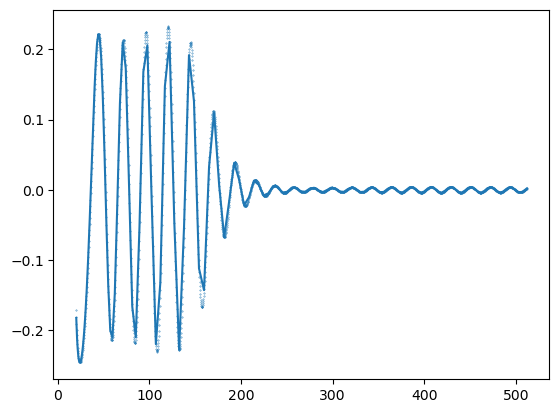

In [4]:
# Plot the spline

X = model._newDrawFromPrior(1)
h = model.getSignal_sparse(X)
det = 'L1'
r = h[det] / model.h0[det]
r0 = r[:, :-1] # Left points (y-intercepts)
r1 = (r[:, 1:] - r[:, :-1]) / model.bin_widths 

plt.scatter(model.fgrid, model.getSignal(X)[det] / model.htrue[det], s=0.1)
plt.plot(model.sparse_grid[1:], (r0 + r1 * model.bin_widths).squeeze())

In [5]:
model.sparse_grid

Array([ 20.        ,  20.27151487,  20.55171168,  20.8410674 ,
        21.14005876,  21.44916197,  21.76885263,  22.09977486,
        22.44245639,  22.79754089,  23.16575057,  23.54776508,
        23.94441861,  24.35654175,  24.78501513,  25.23084557,
        25.69507066,  26.17883873,  26.68335204,  27.20997179,
        27.76009517,  28.33529556,  28.93724278,  29.5677661 ,
        30.22882916,  30.92260151,  31.65143482,  32.41784614,
        33.22460046,  34.07471527,  34.97150045,  35.91850099,
        36.91960433,  37.97907525,  39.10149093,  40.29187627,
        41.55563209,  42.8986594 ,  44.32726061,  45.84824455,
        47.46888693,  49.19692415,  51.04050715,  53.00817938,
        55.10876036,  57.35122661,  59.7445988 ,  62.2976775 ,
        65.01883892,  67.91575864,  70.99505991,  74.26200863,
        77.72018637,  81.37119358,  85.21439874,  89.24680967,
        93.46302338,  97.85531643, 102.41381968, 107.12684805,
       111.98125796, 116.96288433, 122.0569697 , 127.24

In [ ]:
np.digitize(model.fgrid, model.sparse_grid) - 1

In [ ]:
###################################################################
# Plot cross sections
###################################################################


posterior     = jax.jit(lambda X: jnp.exp(-1 * model.potential(X)))
neg_potential = jax.jit(lambda X: -1 * model.potential(X))

for i in range(model.DoF):
    for j in range(i+1, model.DoF):
        print('Getting cross section for %i, %i' % (i,j))
        plot_cross_section(i, j, neg_potential, 200, model.true_params, model.lower_bound, model.upper_bound, model.gwfast_param_order)
        # plot_cross_section(i, j, posterior, 200, model.true_params, model.lower_bound, model.upper_bound, model.gwfast_param_order)

In [ ]:
# posterior     = jax.jit(lambda X: jnp.exp(-1 * model.potential(X)))
neg_potential = jax.jit(lambda X: -1 * model.potential(X))
# neg_potential = lambda X: -1 * model.potential(X)


i = 0
j = 1
# for i in range(model.DoF):
#     for j in range(i+1, model.DoF):
print('Getting cross section for %i, %i' % (i,j))
plot_cross_section(i, j, neg_potential, 200, model.true_params, model.lower_bound, model.upper_bound, model.gwfast_param_order)
        # plot_cross_section(i, j, posterior, 200, model.true_params, model.lower_bound, model.upper_bound, model.gwfast_param_order)

In [ ]:
import jax.numpy as jnp

# Define the original points (x and y = x^2)
x_points = jnp.array([0, 1, 2, 3, 4])
y_points = x_points ** 2

# Points where we want to interpolate
x_new = jnp.array([0.5, 1.5, 2.5, 3.5])

# Interpolation
y_new = jnp.interp(x_new, x_points, y_points)

print("Interpolated values:", y_new)


In [ ]:
x_points = jnp.arange(-10, 11, 1)
y_points = x_points ** 2

plt.plot(x_points, y_points)

x_new = jnp.linspace(-10. ,10. , 50)
y_new = jnp.interp(x_new, x_points, y_points)

plt.plot(x_new, y_new)